# Advanced Task 3 — Energy Consumption Time Series Forecasting

## Objective
Forecast short-term household energy usage using historical time-based patterns.

## Requirements Covered
- Parse and resample time series data
- Engineer time-based features (hour, day-of-week, weekend)
- Compare ARIMA, Prophet, and XGBoost models
- Evaluate using MAE and RMSE
- Plot actual vs forecast

## Dataset
Individual household electric power consumption (UCI)
Expected file:
- `data/household_power_consumption.txt`

If the file is missing, this notebook will auto-download and extract it.

In [7]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# -----------------------
# Paths (auto repo root)
# -----------------------
def find_repo_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "data").exists():
            return p
    return start

ROOT = find_repo_root()
DATA_DIR = ROOT / "data"
OUT_DIR = ROOT / "outputs" / "adv_task3"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT   :", ROOT)
print("DATA   :", DATA_DIR)
print("OUTPUT :", OUT_DIR)

def save_fig(name: str) -> None:
    try:
        out = OUT_DIR / name
        plt.tight_layout()
        plt.savefig(out, dpi=150, bbox_inches="tight")
        print("Saved:", out)
    except Exception as e:
        print("Note: could not save figure:", e)

def mae_rmse(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    return mae, rmse

# -----------------------
# Auto-download from UCI
# -----------------------
UCI_ZIP_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00235/household_power_consumption.zip"
ZIP_PATH = DATA_DIR / "household_power_consumption.zip"
TXT_PATH = DATA_DIR / "household_power_consumption.txt"

def download_and_extract_if_missing():
    if TXT_PATH.exists():
        return

    print("Dataset TXT not found. Downloading from UCI ...")
    urllib.request.urlretrieve(UCI_ZIP_URL, ZIP_PATH)
    print("Downloaded zip:", ZIP_PATH)

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(DATA_DIR)

    if not TXT_PATH.exists():
        # sometimes filename differs in rare mirrors, list extracted
        print("Extracted files:", [p.name for p in DATA_DIR.glob("*")])
        raise FileNotFoundError("Extraction done, but household_power_consumption.txt not found in data/")

download_and_extract_if_missing()
print("TXT dataset path:", TXT_PATH)

ROOT   : f:\coding\DevelopersHub-Advanced-Tasks
DATA   : f:\coding\DevelopersHub-Advanced-Tasks\data
OUTPUT : f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task3
TXT dataset path: f:\coding\DevelopersHub-Advanced-Tasks\data\household_power_consumption.txt


In [8]:
# The file is ';' separated, missing values often represented as '?'
df = pd.read_csv(
    TXT_PATH,
    sep=";",
    low_memory=False,
    na_values=["?", "nan", "NaN", ""]
)

df.columns = df.columns.str.strip()
print("Raw shape:", df.shape)
display(df.head())

# Build datetime
if not {"Date", "Time"}.issubset(df.columns):
    raise ValueError(f"Date/Time columns not found. Columns: {df.columns.tolist()}")

df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["datetime"]).sort_values("datetime")

# Choose target column (common)
TARGET_COL = "Global_active_power"
if TARGET_COL not in df.columns:
    raise ValueError(f"Target '{TARGET_COL}' not found. Available: {df.columns.tolist()}")

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

# Keep only datetime + target
df_ts = df[["datetime", TARGET_COL]].dropna().set_index("datetime")

print("Clean shape:", df_ts.shape)
print("Time range:", df_ts.index.min(), "->", df_ts.index.max())
df_ts.head()

Raw shape: (2075259, 9)


,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0


Clean shape: (2049280, 1)
Time range: 2006-12-16 17:24:00 -> 2010-11-26 21:02:00


,Global_active_power
datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666


Resampled hourly series length: 2880
Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task3\resampled_hourly_series.png


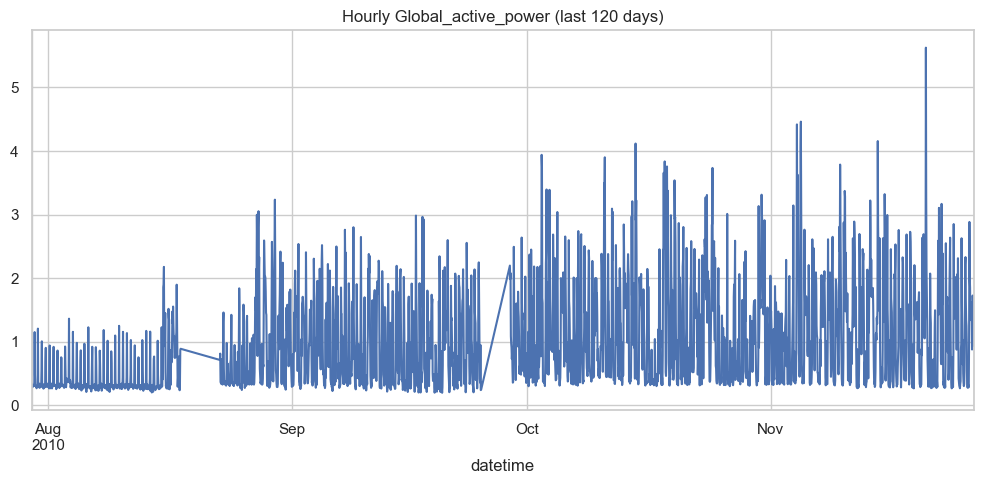

In [9]:
# Resample to hourly mean
ts = df_ts[TARGET_COL].resample("H").mean()

# Fill missing after resample
ts = ts.interpolate(limit_direction="both").dropna()

# Optional: limit to recent history for speed (ARIMA/Prophet can be slow on full dataset)
MAX_DAYS = 120   # adjust: 60/90/180
ts = ts.last(f"{MAX_DAYS}D")

print("Resampled hourly series length:", len(ts))
ts.plot(title=f"Hourly {TARGET_COL} (last {MAX_DAYS} days)")
save_fig("resampled_hourly_series.png")
plt.show()

In [10]:
# Forecast horizon: last 20% as test
split_idx = int(len(ts) * 0.8)
train_ts = ts.iloc[:split_idx]
test_ts = ts.iloc[split_idx:]

print("Train size:", train_ts.shape, "Test size:", test_ts.shape)
print("Test starts at:", test_ts.index.min())

Train size: (2304,) Test size: (576,)
Test starts at: 2010-11-02 22:00:00


## Model 1 — ARIMA (SARIMAX)

We use a seasonal component of 24 hours (daily seasonality for hourly data).
This is a baseline time-series model.

ARIMA MAE : 0.6722
ARIMA RMSE: 0.8558
Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task3\arima_actual_vs_forecast.png


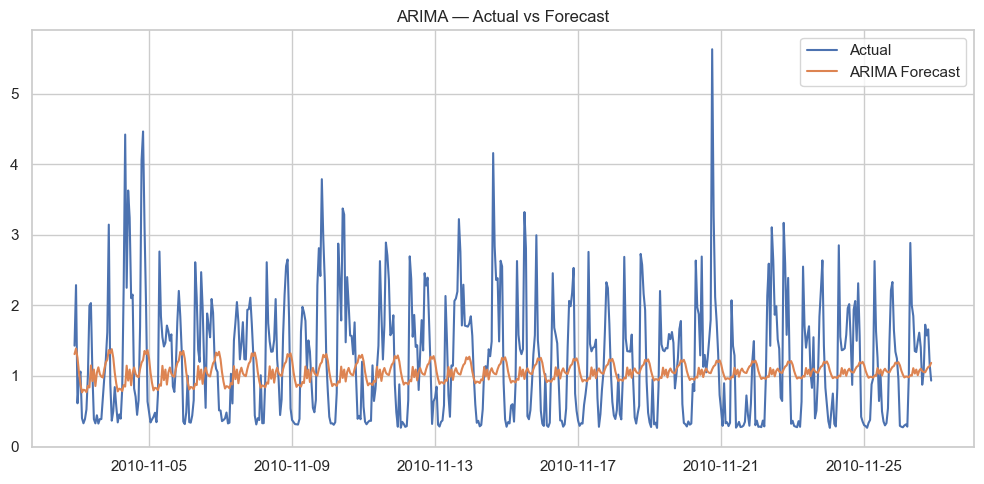

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# A reasonable baseline configuration (you can tune later)
arima = SARIMAX(
    train_ts,
    order=(2, 1, 2),
    seasonal_order=(1, 0, 1, 24),  # daily seasonality
    enforce_stationarity=False,
    enforce_invertibility=False
)

arima_fit = arima.fit(disp=False)

arima_forecast = arima_fit.forecast(steps=len(test_ts))
arima_mae, arima_rmse = mae_rmse(test_ts.values, arima_forecast.values)

print("ARIMA MAE :", round(arima_mae, 4))
print("ARIMA RMSE:", round(arima_rmse, 4))

plt.plot(test_ts.index, test_ts.values, label="Actual")
plt.plot(test_ts.index, arima_forecast.values, label="ARIMA Forecast")
plt.title("ARIMA — Actual vs Forecast")
plt.legend()
save_fig("arima_actual_vs_forecast.png")
plt.show()

## Model 2 — Prophet (optional)

Prophet handles trend and seasonality automatically.
If Prophet is not installed, the notebook will skip this model safely.

Install (if needed):
```bash
pip install prophet

00:56:12 - cmdstanpy - INFO - Chain [1] start processing
00:56:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet MAE : 0.552
Prophet RMSE: 0.7646
Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task3\prophet_actual_vs_forecast.png


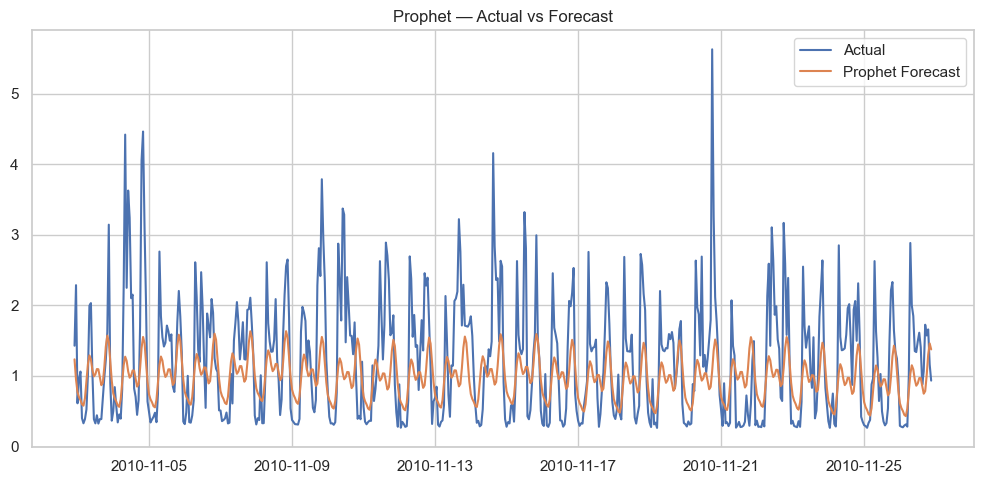

In [12]:
prophet_available = True
try:
    from prophet import Prophet
except Exception as e:
    prophet_available = False
    print("Prophet not available. Skipping Prophet model.")
    print("Install with: pip install prophet")
    print("Reason:", e)

prophet_mae = prophet_rmse = None

if prophet_available:
    train_df = train_ts.reset_index()
    train_df.columns = ["ds", "y"]

    test_df = test_ts.reset_index()
    test_df.columns = ["ds", "y"]

    m = Prophet(daily_seasonality=True, weekly_seasonality=True)
    m.fit(train_df)

    future = test_df[["ds"]]
    fcst = m.predict(future)
    prophet_pred = fcst["yhat"].values

    prophet_mae, prophet_rmse = mae_rmse(test_df["y"].values, prophet_pred)
    print("Prophet MAE :", round(prophet_mae, 4))
    print("Prophet RMSE:", round(prophet_rmse, 4))

    plt.plot(test_df["ds"], test_df["y"], label="Actual")
    plt.plot(test_df["ds"], prophet_pred, label="Prophet Forecast")
    plt.title("Prophet — Actual vs Forecast")
    plt.legend()
    save_fig("prophet_actual_vs_forecast.png")
    plt.show()

## Model 3 — XGBoost (Supervised with Time Features)

We convert time series into a supervised learning problem:
- time features: hour, day-of-week, weekend
- lag features: previous hours (1, 2, 3, 24, 48, 72)

Install (if needed):
```bash
pip install xgboost

XGBoost MAE : 0.3923
XGBoost RMSE: 0.5878
Saved: f:\coding\DevelopersHub-Advanced-Tasks\outputs\adv_task3\xgboost_actual_vs_forecast.png


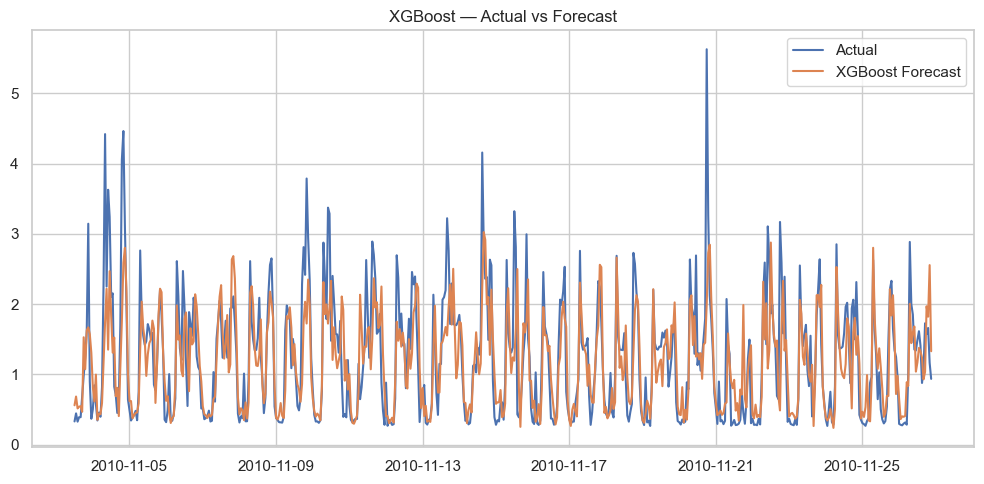

In [13]:
xgb_available = True
try:
    from xgboost import XGBRegressor
except Exception as e:
    xgb_available = False
    print("XGBoost not available. Skipping XGBoost model.")
    print("Install with: pip install xgboost")
    print("Reason:", e)

xgb_mae = xgb_rmse = None

if xgb_available:
    df_feat = ts.to_frame("y").copy()
    df_feat["hour"] = df_feat.index.hour
    df_feat["dayofweek"] = df_feat.index.dayofweek
    df_feat["is_weekend"] = (df_feat["dayofweek"] >= 5).astype(int)

    # lag features
    for lag in [1, 2, 3, 24, 48, 72]:
        df_feat[f"lag_{lag}"] = df_feat["y"].shift(lag)

    df_feat = df_feat.dropna()

    # time-based split
    split_idx2 = int(len(df_feat) * 0.8)
    train_df2 = df_feat.iloc[:split_idx2]
    test_df2 = df_feat.iloc[split_idx2:]

    X_train2, y_train2 = train_df2.drop(columns=["y"]), train_df2["y"]
    X_test2, y_test2 = test_df2.drop(columns=["y"]), test_df2["y"]

    xgb = XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42
    )
    xgb.fit(X_train2, y_train2)

    xgb_pred = xgb.predict(X_test2)
    xgb_mae, xgb_rmse = mae_rmse(y_test2.values, xgb_pred)

    print("XGBoost MAE :", round(xgb_mae, 4))
    print("XGBoost RMSE:", round(xgb_rmse, 4))

    plt.plot(y_test2.index, y_test2.values, label="Actual")
    plt.plot(y_test2.index, xgb_pred, label="XGBoost Forecast")
    plt.title("XGBoost — Actual vs Forecast")
    plt.legend()
    save_fig("xgboost_actual_vs_forecast.png")
    plt.show()

## Model Comparison (MAE / RMSE)

We compare all models on the same test window.
Lower MAE/RMSE indicates better forecast accuracy.

In [14]:
results = [
    {"model": "ARIMA", "mae": arima_mae, "rmse": arima_rmse},
    {"model": "Prophet", "mae": prophet_mae, "rmse": prophet_rmse},
    {"model": "XGBoost", "mae": xgb_mae, "rmse": xgb_rmse},
]

results_df = pd.DataFrame(results)
display(results_df)

,model,mae,rmse
0,ARIMA,0.672163,0.855838
1,Prophet,0.552020,0.764600
2,XGBoost,0.392273,0.587827


## Conclusion (Write after running)

- We resampled the time series to hourly data and handled missing values using interpolation.
- We engineered time features (hour, weekday/weekend) and lag features for XGBoost.
- Based on MAE/RMSE comparison, the best model was: __
- The actual vs forecast plots show: __ (good tracking / lag / peaks missed).
- Next improvements:
  - Tune ARIMA parameters (order/seasonal order)
  - Add rolling features for XGBoost (rolling mean/std)
  - Try longer/shorter forecast horizon